# Customer Feedback Analytics System
## Module 3: Satisfaction Driver Analysis & Customer Segmentation

**Part A - Driver Analysis:** Uses correlation and linear regression to test
which factors (price, discount %, review volume) statistically predict
rating/satisfaction.

**Part B - Segmentation:** Uses K-Means clustering to group products into
meaningful segments based on price, satisfaction, and sentiment - supporting
targeted retention strategy recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats

pd.set_option('display.max_colwidth', 80)

## Part 1: Load and Merge Data

Combine the sentiment-enriched dataset with the CSI scores calculated in
Module 1.

In [2]:
df_sentiment = pd.read_csv("data/feedback_with_sentiment.csv")
df_csi = pd.read_csv("data/csi_by_product.csv")[["product_id", "csi_score", "weighted_csi_score", "satisfaction_band"]]

df = df_sentiment.merge(df_csi, on="product_id", how="left")
print("Merged shape:", df.shape)
df[["product_id", "rating", "csi_score", "vader_compound", "satisfaction_band"]].head(3)

Merged shape: (1350, 21)


,product_id,rating,csi_score,vader_compound,satisfaction_band
0,B07JW9H4J1,4.2,84.0,0.9297,Highly Satisfied
1,B098NS6PVG,4.0,80.0,0.9937,Highly Satisfied
2,B096MSW6CT,3.9,78.0,0.8976,Satisfied


## Part 2: Correlation Analysis

Test the strength of relationship between rating and: price, discount
percentage, and review volume (rating_count).

rating                 1.000000
vader_compound         0.217738
actual_price           0.127064
discounted_price       0.126365
rating_count           0.096852
discount_percentage   -0.161799
Name: rating, dtype: float64


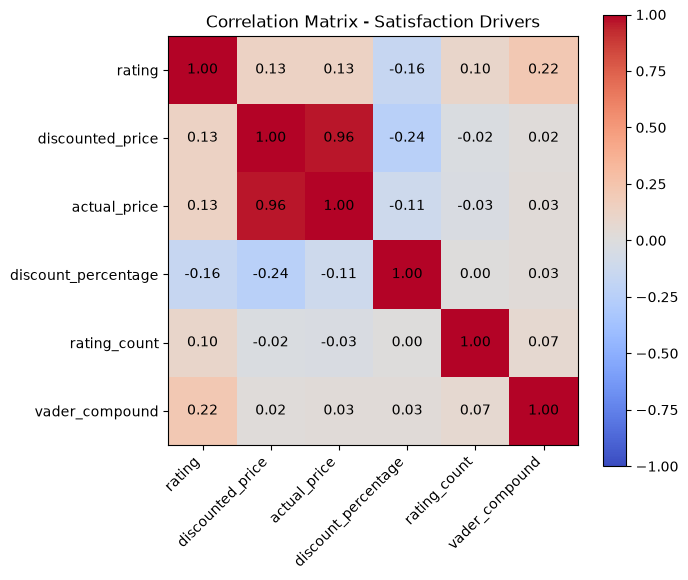

In [3]:
corr_features = ["rating", "discounted_price", "actual_price",
                  "discount_percentage", "rating_count", "vader_compound"]
corr_matrix = df[corr_features].corr()
print(corr_matrix["rating"].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=45, ha="right")
ax.set_yticklabels(corr_features)
for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.colorbar(im)
plt.title("Correlation Matrix - Satisfaction Drivers")
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=150)
plt.show()

## Part 3: Multiple Linear Regression

Model: rating ~ discount_percentage + actual_price + rating_count

This quantifies each factor's independent effect on rating while holding
the others constant, and reports statistical significance (p-values).

In [4]:
reg_df = df[["rating", "discount_percentage", "actual_price", "rating_count"]].dropna()

X = reg_df[["discount_percentage", "actual_price", "rating_count"]]
y = reg_df["rating"]

# Standardize features so coefficients are comparable in magnitude
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

r_squared = model.score(X_scaled, y)
print(f"R-squared: {r_squared:.4f}")
print("\nStandardized coefficients (relative importance):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

# Statistical significance via scipy
print("\nIndividual correlations with significance (p-value):")
for col in ["discount_percentage", "actual_price", "rating_count"]:
    r, p = stats.pearsonr(reg_df[col], reg_df["rating"])
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {col}: r={r:.3f}, p={p:.4f} ({sig})")

R-squared: 0.0484

Standardized coefficients (relative importance):
  discount_percentage: -0.0444
  actual_price: 0.0338
  rating_count: 0.0301

Individual correlations with significance (p-value):
  discount_percentage: r=-0.162, p=0.0000 (significant)
  actual_price: r=0.127, p=0.0000 (significant)
  rating_count: r=0.097, p=0.0004 (significant)


## Part 4: Customer Segmentation via K-Means Clustering

Segment products using price, rating, and sentiment as features. This
identifies natural groupings that can inform targeted retention strategies
(e.g., "high-value, high-satisfaction" vs "budget, at-risk" segments).

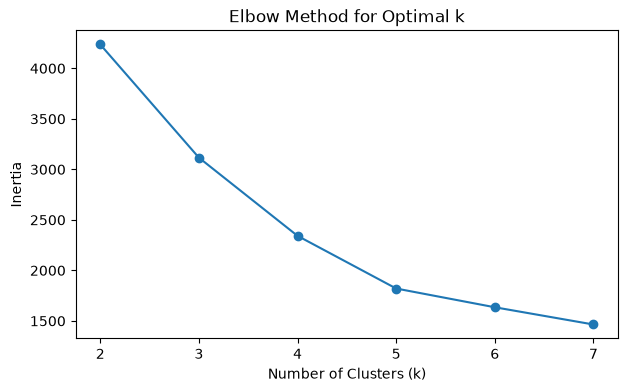

In [5]:
cluster_features = ["discounted_price", "rating", "vader_compound", "discount_percentage"]
cluster_df = df[cluster_features].dropna()

scaler2 = StandardScaler()
X_cluster = scaler2.fit_transform(cluster_df)

# Elbow method to justify choice of k
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.savefig("data/elbow_plot.png", dpi=150)
plt.show()

In [6]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

# Merge cluster labels back to main df
df = df.loc[cluster_df.index].copy()
df["cluster"] = cluster_df["cluster"]

# Profile each cluster
cluster_profile = df.groupby("cluster").agg(
    n_products=("product_id", "count"),
    avg_price=("discounted_price", "mean"),
    avg_rating=("rating", "mean"),
    avg_sentiment=("vader_compound", "mean"),
    avg_discount=("discount_percentage", "mean"),
).round(2).sort_values("avg_rating", ascending=False)

print(cluster_profile)
cluster_profile.to_csv("data/cluster_profile.csv")

         n_products  avg_price  avg_rating  avg_sentiment  avg_discount
cluster                                                                
0               540    2945.97        4.21           0.94         28.39
2                66   29301.97        4.21           0.98         31.02
3               690    1103.50        4.01           0.94         62.59
1                54    3268.89        3.85          -0.55         46.19


## Part 5: Name and Interpret Segments

Assign business-friendly names to each cluster based on its profile
(price level x satisfaction level).

In [7]:
def name_segment(row):
    price_level = "Premium" if row["avg_price"] > cluster_profile["avg_price"].median() else "Budget"
    satisfaction_level = "High-Satisfaction" if row["avg_rating"] > cluster_profile["avg_rating"].median() else "At-Risk"
    return f"{price_level} / {satisfaction_level}"

cluster_profile["segment_name"] = cluster_profile.apply(name_segment, axis=1)
print(cluster_profile[["n_products", "avg_price", "avg_rating", "avg_sentiment", "segment_name"]])

cluster_profile.to_csv("data/cluster_profile.csv")

         n_products  avg_price  avg_rating  avg_sentiment  \
cluster                                                     
0               540    2945.97        4.21           0.94   
2                66   29301.97        4.21           0.98   
3               690    1103.50        4.01           0.94   
1                54    3268.89        3.85          -0.55   

                        segment_name  
cluster                               
0         Budget / High-Satisfaction  
2        Premium / High-Satisfaction  
3                   Budget / At-Risk  
1                  Premium / At-Risk  


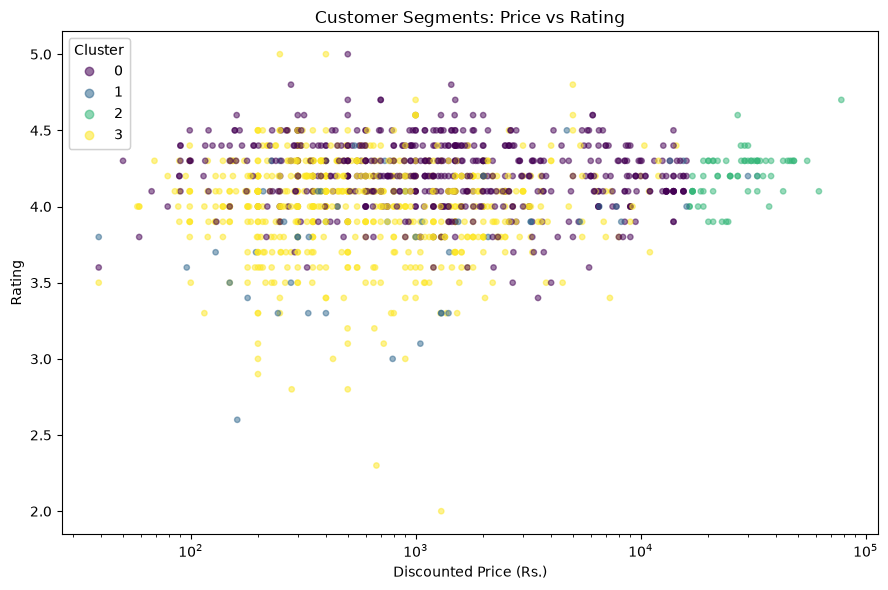

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df["discounted_price"], df["rating"], c=df["cluster"], cmap="viridis", alpha=0.5, s=15)
ax.set_xlabel("Discounted Price (Rs.)")
ax.set_ylabel("Rating")
ax.set_title("Customer Segments: Price vs Rating")
ax.set_xscale("log")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig("data/cluster_scatter.png", dpi=150)
plt.show()

## Part 6: Save Final Enriched Dataset

In [9]:
df.to_csv("data/feedback_final_with_clusters.csv", index=False)
print("Saved feedback_final_with_clusters.csv:", df.shape)

Saved feedback_final_with_clusters.csv: (1350, 22)
